In [ ]:
# pip install mglearn

In [1]:
from sklearn.neural_network import MLPClassifier

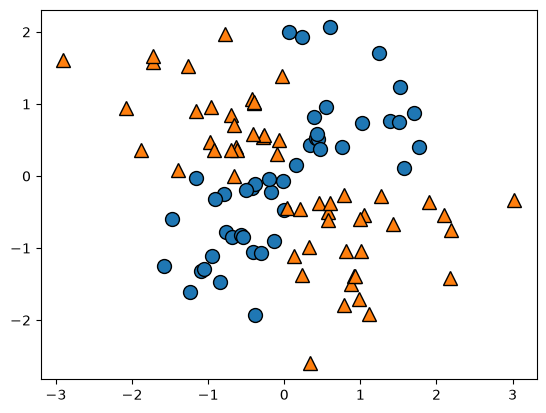

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import mglearn

#200개의 데이터, feature = 2개
np.random.seed(30)
X = np.random.randn(100, 2)
y = np.logical_xor(X[:, 0]>0, X[:, 1]>0)
y = np.where(y, 1, -1)
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                   test_size=0.2,
                                                   shuffle=True)

직접 해보세요.  
1번째 은닉층 : 노드 10개  
2번째 은닉층 : 노드 5개  
3번째 은닉층 : 노드 3개

In [28]:
model_pctr = MLPClassifier(hidden_layer_sizes=( 7, 5, 3 ), max_iter=int(1e+05), random_state=1) # 다층 퍼셉트론

In [29]:
model_pctr.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(7, ...)"
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100000
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",1
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [30]:
model_pctr.score(X_train, y_train)

1.0

In [31]:
model_pctr.score(X_test, y_test)

0.95

#### parameter
- activation  
1) default : relu  
2) logistic (sigmoid)  
3) tanh (sigmoid 일종)  
4) indentity : linear  

- solver
1) default : adam  
2) lbfgs  
3) sgd : stochastic(확률적) gradient decent  

- alpha : l2 norm 규제 정도 (Ridge regression과 동일)

- tol : cost 가 학습을 멈추는 기준 값 (cost = tol 일 될때까지)

- max_iter : optimizing 최대 반복 수

In [32]:
model_pctr.coefs_, model_pctr.intercepts_

([array([[-8.78788291e-34,  9.32417833e-01, -1.71730724e+00,
          -5.40798925e-01, -1.05574780e+00, -1.55850420e+00,
           3.70087126e-01],
         [-1.04747233e-14, -1.27100819e+00, -3.24965714e-01,
          -1.31138300e+00,  4.73215294e-01, -1.05591274e-01,
           1.94986634e+00]]),
  array([[ 6.07583763e-04, -9.56629525e-14,  3.80192023e-13,
           3.07731290e-05,  6.35623073e-05],
         [-8.87582063e-01, -1.09424353e+00, -1.21673554e-01,
           1.61907999e+00, -8.23874730e-05],
         [ 6.92268642e-01,  1.47051681e+00, -1.67278062e+00,
           1.49732087e-01, -5.61212145e-14],
         [ 2.03859885e-01,  1.26016723e+00, -1.76683673e+00,
           1.12791392e+00,  9.89628822e-04],
         [ 1.08302054e+00, -8.12666323e-01,  7.28328349e-02,
          -9.75119640e-01,  1.44475211e-42],
         [ 1.47443401e+00,  3.91255066e-01, -1.18970963e+00,
          -6.67724863e-01, -8.19312950e-04],
         [ 9.14513396e-01, -1.22519678e+00,  7.97265886e-01,
 

In [41]:
#각 층의 coef 개수
count = 0
for i, coef in enumerate(model_pctr.coefs_):
    print('hidden_layer_{}_weight_no: {}'.format(i, coef.shape))
    count += coef.shape[0] * coef.shape[1]
temp = count
print('coef 개수:', count)

for i, intercept in enumerate(model_pctr.intercepts_):
    print('hidden_layer_{}_intercept_no: {}'.format(i, intercept.shape))
    count += intercept.shape[0]
print('intecept 개수:', count-temp)

print('총 weight 개수:', count)

hidden_layer_0_weight_no: (2, 7)
hidden_layer_1_weight_no: (7, 5)
hidden_layer_2_weight_no: (5, 3)
hidden_layer_3_weight_no: (3, 1)
coef 개수: 67
hidden_layer_0_intercept_no: (7,)
hidden_layer_1_intercept_no: (5,)
hidden_layer_2_intercept_no: (3,)
hidden_layer_3_intercept_no: (1,)
intecept 개수: 16
총 weight 개수: 83


총 weight 의 개수는 ?  
coef_ 몇 개인가?  
intercept_ 몇 개인가?  

  각 층마다의 coef_ intercept 는 몇개씩인가?

출력해보세요.

In [42]:
model_pctr.intercepts_[0].shape

(7,)

In [ ]:
## 여기에서 코드를 작성해보세요.

In [43]:
#graph, dataset 확장 패키지
def result_visualization(model, X, y):
    mglearn.plots.plot_2d_separator(model, X,
                                    fill=True, alpha=.1)
    mglearn.discrete_scatter(X[:, 0], X[:, 1], y)

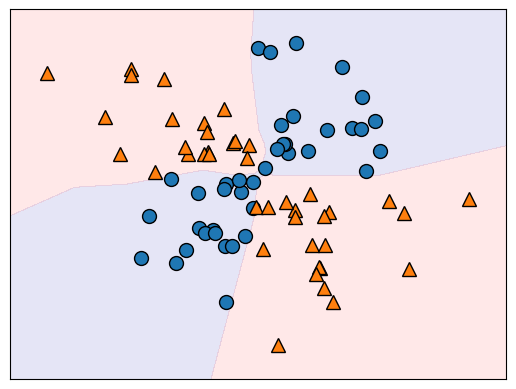

In [44]:
result_visualization(model_pctr, X_train, y_train)

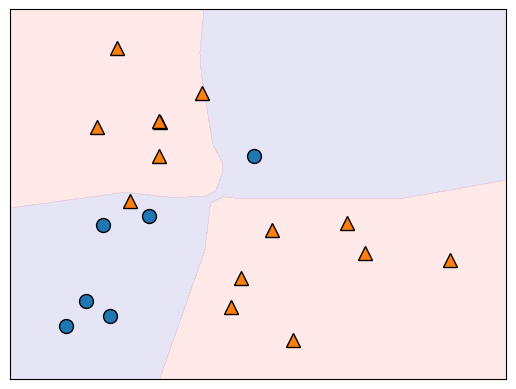

In [45]:
result_visualization(model_pctr, X_test, y_test)

사람 얼굴 인식 문제

In [46]:
from sklearn.datasets import fetch_olivetti_faces

In [ ]:
face_data = fetch_olivetti_faces()
print(face_data.DESCR)

In [48]:
face_data.keys()

dict_keys(['data', 'images', 'target', 'DESCR'])

In [49]:
face_data.data.shape

(400, 4096)

In [50]:
face_data.images.shape

(400, 64, 64)

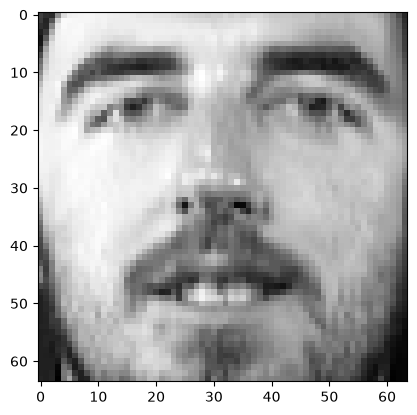

In [67]:
import matplotlib.pyplot as plt

plt.imshow(face_data['images'][100], cmap='gray')
plt.show()

In [51]:
face_data.target.shape

(400,)

In [55]:
len(set(face_data.target))

40

1) 데이터의 총 개수는?
2) 하나의 데이터가 갖고 있는 X_feature의 개수는?
3) 다중 클래스 문제인가?
4) 클래스의 개수는?

- 여기에 답변을 작성하세요

1) 적정한 층 수는?
2) 각 층의 노드는 몇 개가 적당한가?
3) 총 가중치의 개수는? (coef + weight)

In [ ]:
from sklearn.neural_network import MLPClassifier

In [ ]:
# 모델 선택
model = MLPClassifier(hidden_layer_sizes=([80, 40]))

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(face_data.data, face_data.target)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
model.score(X_train, y_train)

In [ ]:
model.score(X_test, y_test)